MERGE SHORT (DIVIDE&CONQUER)

Before sorting: [38, 27, 43, 3, 9, 82, 10]
After sorting: [3, 9, 10, 27, 38, 43, 82]


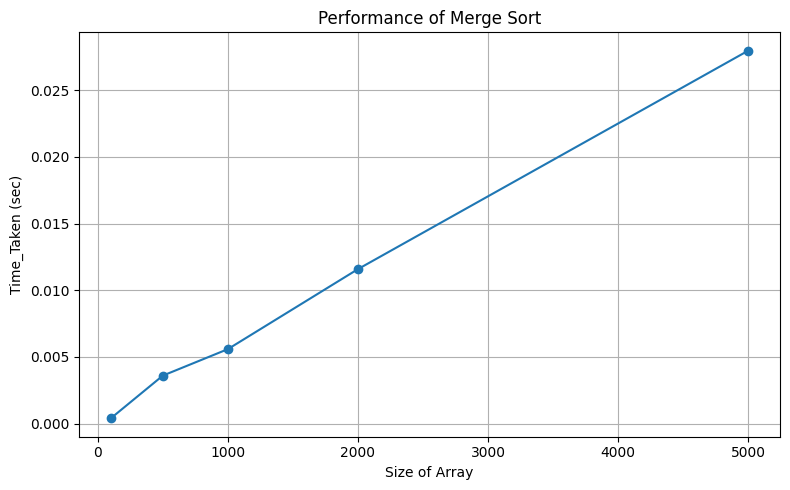

In [2]:
import time
import random
import matplotlib.pyplot as plt


def merge_sort(numbers):
    
    if len(numbers) <= 1:
        return numbers

    middle = len(numbers) // 2

    left_part = merge_sort(numbers[:middle])
    right_part = merge_sort(numbers[middle:])

    return merge_lists(left_part, right_part)


def merge_lists(left, right):

    # Merges two sorted lists into one
    merged = []
    left_index = 0
    right_index = 0

    # Compareing elements

    while left_index < len(left) and right_index < len(right):
        if left[left_index] < right[right_index]:
            merged.append(left[left_index])
            left_index += 1
        else:
            merged.append(right[right_index])
            right_index += 1

    
    merged.extend(left[left_index:])
    merged.extend(right[right_index:])

    return merged



example = [38, 27, 43, 3, 9, 82, 10]
print("Before sorting:", example)

sorted_example = merge_sort(example)
print("After sorting:", sorted_example)



input_sizes = [100, 500, 1000, 2000, 5000]
execution_times = []

for size in input_sizes:
    test_data = [random.randint(1, 10000) for _ in range(size)]

    start_time = time.perf_counter()
    merge_sort(test_data)
    end_time = time.perf_counter()

    total_time = end_time - start_time
    execution_times.append(total_time)



plt.figure(figsize=(8, 5))

plt.plot(input_sizes, execution_times, marker='o')
plt.xlabel("Size of Array")
plt.ylabel("Time_Taken (sec)")
plt.title("Performance of Merge Sort")
plt.grid(True)

plt.tight_layout()
plt.show()

SORTING PERFORMANCE COMPARISON


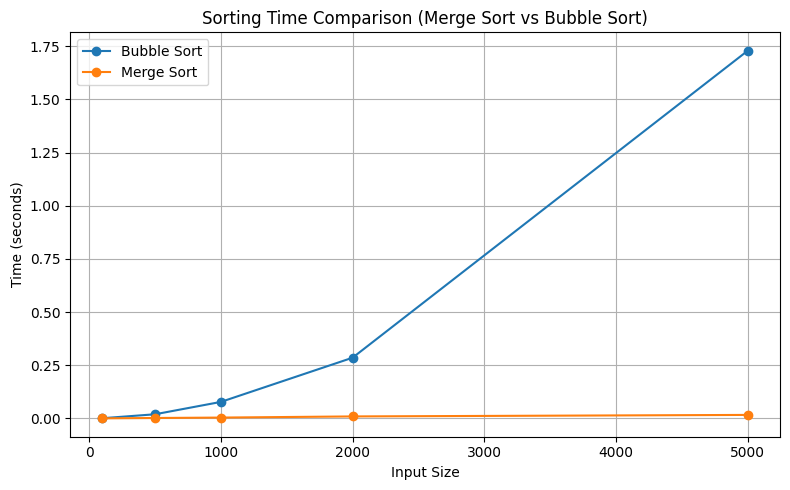

In [3]:
import time
import random
import matplotlib.pyplot as plt


def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result


def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr


sizes = [100, 500, 1000, 2000, 5000]

merge_times = []
bubble_times = []

for size in sizes:
    data1 = [random.randint(1, 10000) for _ in range(size)]
    data2 = data1.copy()

    start = time.perf_counter()
    merge_sort(data1)
    end = time.perf_counter()
    merge_times.append(end - start)

    start = time.perf_counter()
    bubble_sort(data2)
    end = time.perf_counter()
    bubble_times.append(end - start)


plt.figure(figsize=(8, 5))

plt.plot(sizes, bubble_times, marker='o', label='Bubble Sort')
plt.plot(sizes, merge_times, marker='o', label='Merge Sort')

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Sorting Time Comparison (Merge Sort vs Bubble Sort)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Problem 3: Greedy Algorithm (Fractional Knapsack)

In [6]:
values = [25, 110, 114]
weights = [15, 30, 45]
capacity = 34


def sort_items(data):
    if len(data) <= 1:
        return data

    mid = len(data) // 2
    left_half = sort_items(data[:mid])
    right_half = sort_items(data[mid:])

    return combine(left_half, right_half)


def combine(left, right):
    sorted_list = []
    i = j = 0

    while i < len(left) and j < len(right):
        if (left[i][0] / left[i][1]) > (right[j][0] / right[j][1]):
            sorted_list.append(left[i])
            i += 1
        else:
            sorted_list.append(right[j])
            j += 1

    sorted_list.extend(left[i:])
    sorted_list.extend(right[j:])

    return sorted_list


def fractional_knapsack(values, weights, capacity):
    paired_items = list(zip(values, weights))
    sorted_items = sort_items(paired_items)

    max_value = 0

    for val, wt in sorted_items:
        if capacity >= wt:
            max_value += val
            capacity -= wt
        else:
            portion = capacity / wt
            max_value += val * portion
            break

    return max_value


result_value = fractional_knapsack(values, weights, capacity)
print("Maximum value we can obtain:", result_value)

Maximum value we can obtain: 120.13333333333333


Problem 4: Dynammic Programming (Knapsack)

In [7]:
values = [40, 70, 90]
weights = [5, 10, 15]
capacity = 20


def solve_knapsack(capacity, weights, values, n):
    table = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(n + 1):
        for current_weight in range(capacity + 1):

            if i == 0 or current_weight == 0:
                table[i][current_weight] = 0

            elif weights[i - 1] <= current_weight:
                include_item = values[i - 1] + table[i - 1][current_weight - weights[i - 1]]
                exclude_item = table[i - 1][current_weight]
                table[i][current_weight] = max(include_item, exclude_item)

            else:
                table[i][current_weight] = table[i - 1][current_weight]

    return table[n][capacity]


max_profit = solve_knapsack(capacity, weights, values, len(values))
print("Maximum value we can get:", max_profit)

Maximum value we can get: 130
